## Group Members and Responsibilities

This project was completed collaboratively by a team of four, following the workshop's four sequential parts. Each part depended on the completion of the previous one.

| Group Member | Role | Responsibilities |
|---|---|---|
| **Eche Oji (9078881)** | Data Sourcing & Exploratory Data Analysis | Collected California and Ontario housing price data from a CSV source, a housing/open-data API, and a relational database; built `notebooks/EDA.ipynb` demonstrating all three sources; performed initial EDA (`.head()`, `.info()`, `.describe()`, distributions, missing values) and identified the target variable and single predictor for regression. |
| **Antonio Sainz (9072844)** | Preprocessing & Linear Regression | Preprocessed the selected dataset (missing values, normalization, train/test split); implemented univariate linear regression from scratch (hypothesis, MSE cost, gradient descent) and with `scikit-learn`; evaluated both with RMSE, MAE, and R², and produced the regression visualizations in `notebooks/linear_regression.ipynb`. |
| **Sultan Atanda (9114837)** | Modularization & MLOps Configuration | Converted the working data-loading and regression code into modular, config-driven source files (`src/data_loader.py`, `preprocessing.py`, `model.py`, `evaluation.py`); built `configs/experiment_config.yaml`; established the full project structure and connected all modules into a single reproducible pipeline. |
| **John Buni (9115726)** | Experiment Tracking, Documentation & Final Integration | Implemented experiment logging to `experiments/results.csv`; wrote `requirements.txt` and `README.md`; updated `RobotPM_MLOps.ipynb` with the project's architectural changes; ran final end-to-end testing across the whole repository before submission. |

### Team Workflow

The four parts form a single sequential pipeline, each stage depending on the one before it:

**Data Sourcing & EDA → Preprocessing & Regression Modeling → Modularization & MLOps Configuration → Experiment Tracking, Documentation & Final Integration**

# Modularization Demo

Demonstrates the `src/` modules, each worker in its own cells:
`config` -> `data_loader` -> `preprocessing` -> `model` -> `evaluation`.

This notebook uses a small synthetic sample so it runs standalone. Once
merged with the team's real `data/raw/*.csv` and `data/housing_data.sqlite`
from Part 1, the same cells run unchanged against the real data — only
`configs/experiment_config.yaml` needs updating if paths differ.

## Load configuration

Everything downstream reads from `experiment_config.yaml` instead of hard-coded values.

In [12]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)  # so every relative path in the YAML resolves consistently
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from configs.config import ExperimentConfig

config = ExperimentConfig.from_yaml(PROJECT_ROOT / "configs" / "experiment_config.yaml")
print("Feature:", config.feature)
print("Target:", config.target)
print("Training settings:", config.training)

Feature: median_income
Target: median_house_value
Training settings: {'test_size': 0.2, 'random_state': 42, 'learning_rate': 0.01, 'iterations': 1000}


## 2. `data_loader.py` — DataLoader

Demonstrates the CSV and database loaders. (The live API call is skipped in this sandbox — no network access here — but `DataLoader.load_api()` uses the same request/JSON pattern Part 1 validated in `EDA.ipynb`.)

In [13]:
from src.data_loader import DataLoader

loader = DataLoader(config)

# CSV
california = loader.load_csv(PROJECT_ROOT / config.csv_paths["california"])
print("CSV loaded:", california.shape)
display(california.head())

CSV loaded: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
# Database (SQLite)
db_df = loader.load_database(
    PROJECT_ROOT / config.database["path"],
    config.database["query"],
)
print("Database query loaded:", db_df.shape)
display(db_df.head())

Database query loaded: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [15]:
# API — same call the team validated in EDA.ipynb; run this cell once
# network access is available in your environment.
try:
    api_df = loader.load_api(
        config.api["url"],
        params=config.api.get("params"),
        record_path=config.api.get("record_path"),
    )
    print("API loaded:", api_df.shape)
    display(api_df.head())
except Exception as exc:
    print(f"API call skipped in this environment: {exc}")

API loaded: (100, 70)


,_id,JURIS_NAME,CNTY_NAME,YEAR,PRIOR_APN,APN,STREET_ADDRESS,PROJECT_NAME,JURS_TRACKING_ID,UNIT_CAT,...,DEM_DES_UNITS_OWN_RENT,DENSITY_BONUS_TOTAL,DENSITY_BONUS_NUMBER_OTHER_INCENTIVES,DENSITY_BONUS_INCENTIVES,DENSITY_BONUS_RECEIVE_REDUCTION,NOTES,LATITUDE,LONGITUDE,STD_ADDRESS,SCORE
0,1,STANISLAUS COUNTY,Stanislaus,2020,None,010-010-036,12420 LANCASTER RD,NaN,BLD2020-0646,MH,...,0,0,0,None,None,MANUFACTURED DWELLING - 2020 PALM HARBOR - 283...,37.782452,-120.766065,"12420 Lancaster Rd, Oakdale, California, 95361",88.969999999999999
1,2,STANISLAUS COUNTY,Stanislaus,2020,None,045-030-030,4418 Martha ST,NaN,BLD2020-0510,ADU,...,0,0,0,None,None,CONVERT EXISTING DETACHED GARAGE / APARTMENT T...,37.555557,-120.911559,"4418 Martha Ave, Keyes, California, 95328",86.159999999999997
2,3,STANISLAUS COUNTY,Stanislaus,2020,None,024-034-002,3218,FRESNO AVE,BLD2019-2660,ADU,...,0,0,0,None,None,CONVERT 328 SQ. FT. OF EXISTING ATTACHED GARA...,37.559009,-120.997660,NaN,82.609999999999999
3,4,STANISLAUS COUNTY,Stanislaus,2020,None,010-082-007,11510 RODDEN RD,NaN,BLD2019-2736,ADU,...,0,0,0,None,None,ACCESSORY DWELLING UNIT ( 1200 SQ. FT. ) WITH ...,37.790186,-120.784437,"11510 Rodden Rd, Oakdale, California, 95361",88.359999999999999
4,5,STANISLAUS COUNTY,Stanislaus,2020,None,062-019-030,6939 CENTRAL AVE,NaN,BLD2020-1893,ADU,...,0,0,0,None,None,((ACA)) INSTALLATION OF MANUFACTURED HOME - AD...,37.496761,-120.846802,"N Center St, Turlock, California, 95380",80.25


## 3. `preprocessing.py` — Preprocessor

Selects the configured feature/target, drops missing rows, splits 80/20, and standardizes (fit on train only).

In [16]:
from src.preprocessing import Preprocessor

preprocessor = Preprocessor.from_config(config)
split = preprocessor.run(california)

print("X_train:", split.X_train.shape, " X_test:", split.X_test.shape)
print("Train mean/std after scaling:", split.X_train.mean().round(4), split.X_train.std().round(4))

X_train: (16512, 1)  X_test: (4128, 1)
Train mean/std after scaling: -0.0 1.0


## 4. `model.py` — ScratchLinearRegression & SklearnLinearRegression

Both implement the same `BaseRegressionModel` interface (`fit` / `predict`), so they're interchangeable everywhere else.

In [17]:
from src.model import ScratchLinearRegression, SklearnLinearRegression

scratch_model = ScratchLinearRegression(
    learning_rate=config.learning_rate,
    iterations=config.iterations,
).fit(split.X_train, split.y_train)

print(f"theta_0={scratch_model.theta_0:.4f}  theta_1={scratch_model.theta_1:.4f}")
print(f"Final training MSE: {scratch_model.cost_history[-1]:,.2f}")

theta_0=207194.6934  theta_1=79851.9563
Final training MSE: 6,991,447,170.18


In [18]:
sklearn_model = SklearnLinearRegression().fit(split.X_train, split.y_train)
print(f"intercept={sklearn_model.intercept_:.4f}  coef={sklearn_model.coef_:.4f}")

intercept=207194.6937  coef=79851.9564


## 5. `evaluation.py` — Evaluator

Metrics, a side-by-side comparison table, a regression plot, and CSV experiment logging.

In [19]:
from src.evaluation import Evaluator

evaluator = Evaluator()

results = [
    evaluator.compute_metrics(scratch_model.name, split.y_test, scratch_model.predict(split.X_test)),
    evaluator.compute_metrics(sklearn_model.name, split.y_test, sklearn_model.predict(split.X_test)),
]
comparison = evaluator.compare(results)
display(comparison.round(4))

,Model,RMSE,MAE,R2
0,From scratch,84209.0124,62990.8652,0.4589
1,Scikit-learn,84209.0124,62990.8653,0.4589


C:\Users\KING\AppData\Local\Temp\ipykernel_29792\3986655325.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


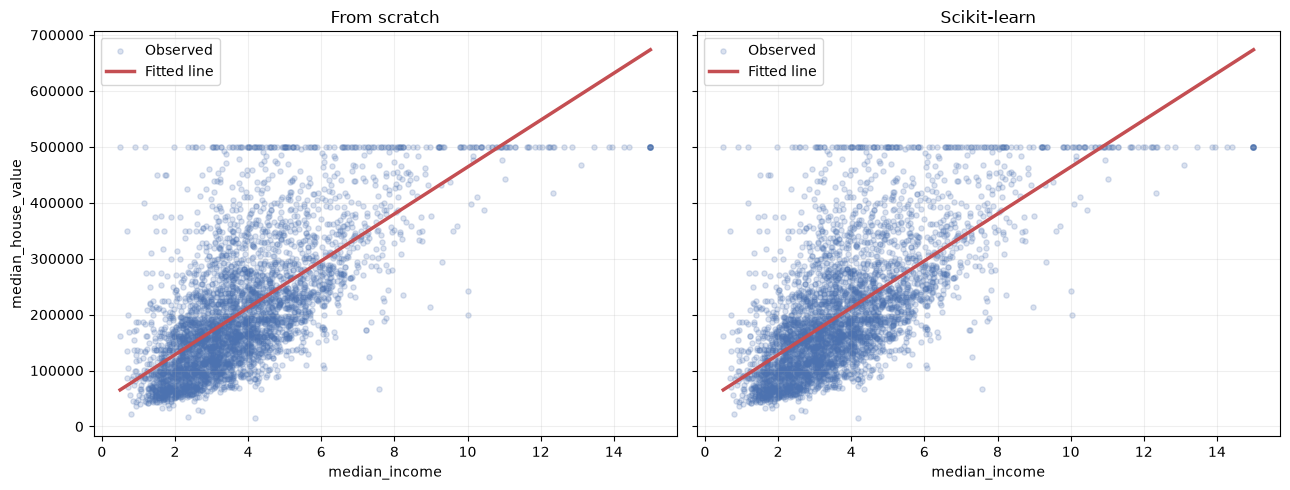

In [20]:
fig = evaluator.plot_regression(
    X_raw=split.X_test_raw[config.feature],
    y_true=split.y_test,
    fitted_models={scratch_model.name: scratch_model, sklearn_model.name: sklearn_model},
    feature_name=config.feature,
    target_name=config.target,
    scaler=preprocessor.scaler,
)
fig.show()

In [21]:
# Config-driven experiment tracking: appends a row per run to experiments/results.csv
for row in results:
    row.update({
        "predictor": config.feature,
        "learning_rate": config.learning_rate,
        "iterations": config.iterations,
        "test_size": config.test_size,
    })

logged = evaluator.save_results(results, PROJECT_ROOT / config.results_path, append=True)
display(logged.tail())

,Model,RMSE,MAE,R2,predictor,learning_rate,iterations,test_size
0,From scratch,84209.012414,62990.865238,0.458859,median_income,0.01,1000,0.2
1,Scikit-learn,84209.012414,62990.865301,0.458859,median_income,0.01,1000,0.2


## 6. End-to-end via config only

Same pipeline, but driven entirely by `load_from_config()` — the pattern the rest of the team can call without touching any module internals.

In [22]:
all_sources = DataLoader(config).load_from_config()
print("Sources loaded from config:", list(all_sources.keys()))

Sources loaded from config: ['california', 'toronto', 'api', 'database']
